In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\orders.csv")

prior = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\order_products__prior.csv")

train = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\order_products__train.csv")

products = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\products.csv")

aisles = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\aisles.csv")

departments = pd.read_csv(r"C:\Users\matth\Downloads\Customer segementation Unzipped Data\departments.csv")

# Customer Segmentation: RFM and K-Means Clustering

## Data Preparation

Before constructing the RFM features and applying K-Means clustering, the integrated analytical dataset (`preprocessed_df`) from `01_data_understanding_preprocessing_cohort_analysis.ipynb` was recreated.

The prior and train order-product datasets were combined and merged with customer order information, product information, aisle information, and department information. The resulting dataset serves as the basis for subsequent RFM feature engineering and clustering.

In [2]:
# Combine prior and train order-product datasets
order_products = pd.concat([prior, train],axis=0,ignore_index=True)

# Merge with orders table
preprocessed_df = order_products.merge(orders,on="order_id",how="left")

# Merge with products table
preprocessed_df = preprocessed_df.merge(products,on="product_id",how="left")

# Merge with aisles table
preprocessed_df = preprocessed_df.merge(aisles,on="aisle_id",how="left")

# Merge with departments table
preprocessed_df = preprocessed_df.merge(departments,on="department_id",how="left")

print("Final preprocessed dataset:")
print(preprocessed_df.isnull().sum())
print("Duplicates:", preprocessed_df.duplicated().sum())
print(preprocessed_df.shape)
preprocessed_df.head()

Final preprocessed dataset:
order_id                        0
product_id                      0
add_to_cart_order               0
reordered                       0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_name                    0
aisle_id                        0
department_id                   0
aisle                           0
department                      0
dtype: int64
Duplicates: 0
(33819106, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


In [3]:
# Recency proxy: average days between orders
# First orders are excluded because they have no prior order interval

orders_without_first = orders[orders["order_number"] > 1].copy()

recency = orders_without_first.groupby("user_id")["days_since_prior_order"].mean().reset_index(name="R_avg_days_between_orders")
recency.head()

,user_id,R_avg_days_between_orders
0,1,19.000000
1,2,16.285714
2,3,12.000000
3,4,17.000000
4,5,11.500000


In [4]:
# Frequency: Total number of orders per customer
frequency = orders.groupby("user_id")["order_number"].max().reset_index(name="F_total_orders")
frequency.head()

,user_id,F_total_orders
0,1,11
1,2,15
2,3,13
3,4,6
4,5,5


In [5]:
# Monetary: Average products per order

# Number of products per order
order_size = preprocessed_df.groupby(["user_id", "order_id"])["product_id"].count().reset_index(name="products_per_order")

monetary = order_size.groupby("user_id")["products_per_order"].mean().reset_index(name="M_avg_products_per_order")
monetary.head()

,user_id,M_avg_products_per_order
0,1,6.363636
1,2,15.066667
2,3,7.333333
3,4,3.600000
4,5,9.200000


In [6]:
# Merge RFM features
rfm_df = frequency.merge(recency, on="user_id", how="left")
rfm_df = rfm_df.merge(monetary, on="user_id", how="left")

print("RFM shape before handling missing values:", rfm_df.shape)
print(rfm_df.isnull().sum())

RFM shape before handling missing values: (206209, 4)
user_id                      0
F_total_orders               0
R_avg_days_between_orders    0
M_avg_products_per_order     0
dtype: int64


In [7]:
print(recency.shape)
print(frequency.shape)
print(monetary.shape)
print(rfm_df.shape)
print(rfm_df.isnull().sum())

(206209, 2)
(206209, 2)
(206209, 2)
(206209, 4)
user_id                      0
F_total_orders               0
R_avg_days_between_orders    0
M_avg_products_per_order     0
dtype: int64


In [8]:
rfm_df.describe()

,user_id,F_total_orders,R_avg_days_between_orders,M_avg_products_per_order
count,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,16.590367,15.448686,9.984527
std,59527.555167,16.654774,6.915575,5.840846
min,1.000000,4.000000,0.000000,1.000000
25%,51553.000000,6.000000,9.814815,5.777778
50%,103105.000000,10.000000,15.000000,9.000000
75%,154657.000000,20.000000,20.625000,13.000000
max,206209.000000,100.000000,30.000000,60.500000


In [9]:
from sklearn.preprocessing import StandardScaler
rfm_features = rfm_df[["R_avg_days_between_orders", "F_total_orders", "M_avg_products_per_order"]]

# Standardize features
scaler = StandardScaler()
cluster_features = scaler.fit_transform(rfm_features)

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Evaluate different k values on the standardized RFM features using Silhouette Score and inertia
k_results = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(cluster_features)

    k_results.append({
        "k": k,
        "silhouette_score": silhouette_score(cluster_features, labels),
        "inertia": kmeans.inertia_
    })

k_results_df = pd.DataFrame(k_results)

print("K selection results:")
print(k_results_df)

K selection results:
    k  silhouette_score        inertia
0   2          0.320839  418090.559486
1   3          0.330000  308448.896876
2   4          0.337257  219605.964873
3   5          0.314753  192293.619723
4   6          0.302116  166758.018497
5   7          0.293589  146426.505539
6   8          0.283593  130801.550626
7   9          0.291576  119643.600585
8  10          0.285635  110428.912571


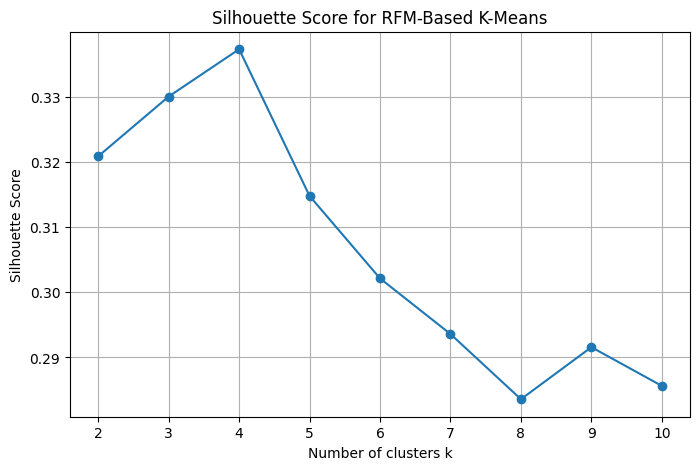

In [11]:
# Plot the Silhouette Scores for the tested k values
plt.figure(figsize=(8, 5))
plt.plot(k_results_df["k"], k_results_df["silhouette_score"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for RFM-Based K-Means")
plt.xticks(range(2, 11))
plt.grid(True)
plt.savefig("silhouette_score_rfm_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

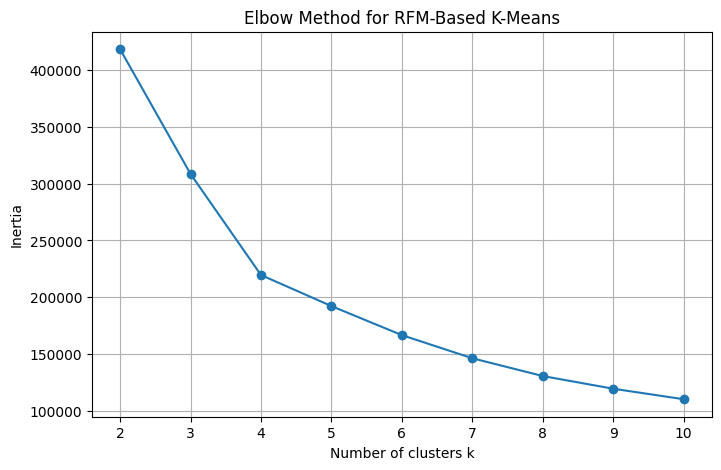

In [12]:
# Plot inertia values to inspect the elbow point
plt.figure(figsize=(8, 5))
plt.plot(k_results_df["k"], k_results_df["inertia"], marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method for RFM-Based K-Means")
plt.xticks(range(2, 11))
plt.grid(True)
plt.savefig("elbow_method_rfm_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Fit the final K-Means model and assign the cluster labels back to the customer IDs
final_k = 4

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(cluster_features)

rfm_df = rfm_df.copy()
rfm_df["rfm_kmeans_segment"] = cluster_labels

print("Final cluster counts:")
print(rfm_df["rfm_kmeans_segment"].value_counts().sort_index())

rfm_df.head()

Final cluster counts:
rfm_kmeans_segment
0    38120
1    67425
2    21924
3    78740
Name: count, dtype: int64


,user_id,F_total_orders,R_avg_days_between_orders,M_avg_products_per_order,rfm_kmeans_segment
0,1,11,19.000000,6.363636,1
1,2,15,16.285714,15.066667,0
2,3,13,12.000000,7.333333,3
3,4,6,17.000000,3.600000,1
4,5,5,11.500000,9.200000,3


In [14]:
cluster_profile = rfm_df.groupby("rfm_kmeans_segment")[["R_avg_days_between_orders", "F_total_orders", "M_avg_products_per_order"]].mean().round(2)
cluster_profile

,R_avg_days_between_orders,F_total_orders,M_avg_products_per_order
rfm_kmeans_segment,,,
0,16.29,12.39,18.96
1,22.68,7.39,7.45
2,6.43,55.98,10.09
3,11.36,15.54,7.78


In [15]:
rfm_df.to_csv("rfm_kmeans_customer_segments.csv", index=False)